# End of week 1 😀😔

Progress you have made...

In [ ]:
def palindrome(s):
    for i in range(len(s) // 2):
        if s[i] != s[-i-1]:
            return False
    return True

Before Monday, it would have looked like:

```python
定義 palindrome(s):
    為了 i in 範圍(長度(s) 劃分 2):
        如果 s[i] 不相等 s[-i-1]:
            返回 False
    返回 True
```

In [ ]:
def enc_letter(a):
    index = lowercase.find(a)
    encrypt = -index-1
    r = lowercase[encrypt]
    return r

def enc(s):
    res = ""
    for a in s:
        res += enc_letter(a)
    return res

In [ ]:
from PIL import Image
import numpy as np
import IPython.display as dsp
from ipywidgets import interact, interactive, fixed, Box
import ipywidgets as widgets


def empty_screen(w=100, h=100):
    res = [[color(255, 255, 255) for i in range(h)] for j in range(w)]
    return res


def color(red=0, green=0, blue=0):
    return (red, green, blue)


def array_to_image(array, scale=2):
    w = len(array)
    h = len(array[0])
    data = np.zeros((h*scale, w*scale, 3), dtype=np.uint8)
    for i in range(w):
        for j in range(h):
            for k in range(scale):
                for l in range(scale):
                    data[(h-1)*scale-(j*scale + k), i*scale+l] = array[i][j]
    img = Image.fromarray(data, 'RGB')
    img.save('my.png')
    return dsp.Image(filename='my.png')


def plot_array(array, scale=2):
    dsp.clear_output(True)
    dsp.display_png(array_to_image(array, scale))
    # sys.stdout.flush()

# Fun exercises from AddisCoder Week 3

In [ ]:
import math


def sine(angle):
    return math.sin((angle/360.0)*2*math.pi)


def cosine(angle):
    return math.cos((angle/360.0)*2*math.pi)

In [ ]:
def cannon(angle, speed, time, gravity=9.8):
    x = speed*time*cosine(angle)
    y = speed*time*sine(angle) - (gravity/2.0)*(time**2)
    return round(x, 3), round(y, 3)


def draw_cannon(angle, speed):
    s = empty_screen(100, 100)
    x = 0
    y = 0
    t = 0.0
    while x < 100 and y >= 0 and y < 100:
        s[x][y] = color(red=255)
        (x, y) = cannon(angle, speed, t)
        x = int(x)
        y = int(y)
        t += 1.0/speed
        plot_array(s)

In [ ]:
def RGB(width, height, red, green, blue):

    # Answer

    s = empty_screen(width, height)
    for i in range(len(s)):
        for j in range(len(s[i])):
            s[i][j] = color(red, green, blue)
    return s

Now create another array (named screen) of size 100x100 that corresponds to your favorite color.

In [ ]:
screen = RGB(100, 100, 0, 0, 255)
array_to_image(screen)

In [ ]:
left = widgets.Button(description='Left')
right = widgets.Button(description='Right')
up = widgets.Button(description='Up')
down = widgets.Button(description='Down')

items = [left, up, down, right]
controllers = Box(children=items)

# Left


def leftB(button):
    global x
    global screen
    if x > 0:
        screen[x][y] = color(0, 0, 0)
        x = x-1
        screen[x][y] = color(255, 255, 255)
    dsp.clear_output(wait=True)
    display(controllers)
    display(array_to_image(screen))


left.on_click(leftB)

# Answer

# Right


def rightB(button):
    global x
    global screen
    if x < 99:
        screen[x][y] = color(0, 0, 0)
        x = x+1
        screen[x][y] = color(255, 255, 255)
    dsp.clear_output(wait=True)
    display(controllers)
    display(array_to_image(screen))


right.on_click(rightB)

# Up


def upB(button):
    global y
    global screen
    if y < 99:
        screen[x][y] = color(0, 0, 0)
        y = y+1
        screen[x][y] = color(255, 255, 255)
    dsp.clear_output(wait=True)
    display(controllers)
    display(array_to_image(screen))


up.on_click(upB)

# Down


def downB(button):
    global y
    global screen
    if y > 0:
        screen[x][y] = color(0, 0, 0)
        y = y-1
        screen[x][y] = color(255, 255, 255)
    dsp.clear_output(wait=True)
    display(controllers)
    display(array_to_image(screen))


down.on_click(downB)

We now have created an interactive way to control the white dot in our screen!

This gives us a really simple drawing program!

Box(children=(Button(description='Left', style=ButtonStyle()), Button(description='Up', style=ButtonStyle()), …

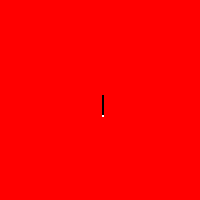

In [65]:
screen = RGB(100,100, 255, 0, 0)
display(controllers)
display(array_to_image(screen))

## Challenge: Passing Game

Prepare a game for two players that will work as follows:

Each player chooses a _position_, _angle_ and _speed_ for their football player.

Then the two footballers pass the ball to each other. Add a point to a player if they pass the ball to the other player's footballer successfully.

The next function is provided to help you begin working on the game! Take a few minuits to look at it and make sure you understund how everyting works.

In [ ]:
def passing_game(width=100, height=100, points1=0, points2=0):
    # Input from the users
    location1 = 0 # int(input("Player 1, enter your location: "))
    location2 = 100 # width - int(input("Player 2, enter your location: "))
    angle1 = int(input("Player 1, enter your angle: "))
    speed1 = int(input("Player 1, enter your speed: "))
    angle2 = 180-int(input("Player 2, enter your angle: "))
    speed2 = int(input("Player 2, enter your speed: "))

    # Function to draw the ball trajectories
    draw_two_trajectories(angle1, speed1, location1, angle2,
                          speed2, location2, width, height)
    
    print(f"Player 1: speed {speed1} at angle {angle1}, Player 2: speed {speed2} at angle {180-angle2}")
    
    not_hit = True
    # Test if a pass is successful and allocate points
    if will_it_hit(angle1, speed1, location2-location1):
        not_hit = False
        points1 = points1 + 1
        print("Player 1 has successfully passed the ball to Player 2!")
        print("Player 1 has ", points1, " points!")
    if will_it_hit(180-angle2, speed2, location2-location1):
        not_hit = False
        points2 = points2 + 1
        print("Player 2 has successfully passed the ball to Player 1!")
        print("Player 2 has ", points2, " points!")
    
    if not_hit:
        print("No player successfully passed the ball")
    # Recursivly continue playing the game until you are bored
    stop = str(input("Continue playing? Y/N "))
    if stop == "N" or stop == "n":
        if points1 > points2:
            print("Player 1 won.")
        elif points1 < points2:
            print("Player 2 won.")
        else:
            print("It's a tie.")
        print("The final score is: ", points1, "-", points2)
    else:
        passing_game(width, height, points1, points2)

In [ ]:
def draw_two_trajectories(angle1, speed1, location1, angle2, speed2, location2, width, height):
    """
    Draw in two colors the trajectory of two passes from these locations at the given widths and angles.
    Use a screen of the given width and height
    """

    # Answer

    s = empty_screen(width, height)

    # initialise 1st player
    x1 = location1
    y1 = 0
    t1 = 0.0

    # initialise 2nd player
    x2 = location2
    y2 = 0
    t2 = 0.0

    while y1 >= 0 or y2 >= 0:
        # check if you are in the range of the array
        if y1<0 and (x2<0 or x2>width):
            break
        if y2<0 and (x1<0 or x1>width):
            break
        if (x2<0 or x2>width) and (x1<0 or x1>width):
            break
        if y1 >= 0 and y1 < height and x1 >= 0 and x1 < width:
            s[x1][y1] = color(red=255)
        if y2 >= 0 and y2 < height and x2 >= 0 and x2 < width:
            s[x2][y2] = color(blue=255)

        # calculate the new values of x1 & y1
        (x1, y1) = cannon(angle1, speed1, t1)
        x1 = int(location1 + int(x1))
        y1 = int(y1)
        t1 += 1.0/speed1
        # calculate the new values of x2 & y2
        (x2, y2) = cannon(angle2, speed2, t2)
        x2 = int(location2 + int(x2))
        y2 = int(y2)
        t2 += 1.0/speed2

        plot_array(s)

In [ ]:
def will_it_hit(angle, speed, distance):
    """
    Return True if a pass (with given speed and angle) will land back on the ground 
    within five units (-3/+3) from the given distance.
    """

    # Answer

    # initialise
    x = 0
    y = 0
    t = 0.0

    # as before calculate the trajectory of the ball,
    # but this time we are only interested in the final possition
    while y >= 0:
        (x, y) = cannon(angle, speed, t)
        x = int(x)
        y = int(y)
        t += 1.0/speed

    # check if x is within 3 units from distance
    #print(distance, x)
    if x >= distance-3 and x <= distance+3:
        return True
    else:
        return False

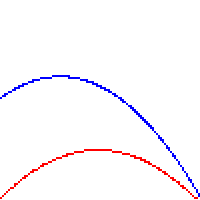

Player 1: speed 31 at angle 45, Player 2: speed 40 at angle 60
Player 1 has successfully passed the ball to Player 2!
Player 1 has  1  points!
Continue playing? Y/N N
Player 1 won.
The final score is:  1 - 0


In [66]:
passing_game(width=100, height=100, points1=0, points2=0)

In [ ]:
from IPython.display import Video

__Another example:__ Given some network of connections - is there a way to reach from one point to the other. 

<img src="https://i.imgur.com/a3HeUAs.jpg"  style="width: 500px;"/>

In [67]:
Video("connectivity.mp4")

# Ask me anything

# Thank you!!! 

### Enjoy the weekend and rest of the program!!!